In [44]:
import json 

with open("./linear_original.jsonl", "r") as f:
    data = [json.loads(line) for line in f]
    
# Example
print(data[0])

{'sokoban_map': '###\n#.#\n# #\n#$#\n# #\n#@#\n###\n', 'source_id': 0, 'split': 'linear', 'level_name': 'linear_w_001_h_005_r_090.sok', 'width': 1, 'height': 5, 'rotation': 90}


In [45]:
prompt = "You are an assistant that helps in solving assigned Sokoban games.\nYour task is to examine the provided Sokoban problem and find a solution.\nAll provided Sokoban problems are assigned in form of ASCII maps.\nThe mapping is the following:\n'''\n@ - Player\n+ - Player on Goal\n$ - Box\n* - Box on Goal\n. - Goal ( Empty )\n# - Wall Brick\n'''\nThe game is solved when the box is pushed into the goal position, hence when the position of '$' coincides with the position of '.'.\nThe player can move in all the empty spaces of the ASCII map while respecting the walls.\nWhen the player is adjacent to a box, the player can push the box into an adjacent empty space.\nAfter pushing a box, the new position of the agent will be the position of the box before the push.\nThe player cannot pull the box, only push it.\nThe actions you can perform in the game are:\n'''\nL - Move Left\nR - Move Right\nU - Move Up\nD - Move Down\n'''\nAll provided problems CAN be solved.\nYou must give your solution in form of a sequence of allowed actions, separated by commas.\nYou must give only the sequence of actions, without any additional text or explanation.\nYou must enclose your solution inside the tags <plan> </plan>.\nThe following is an example of a Sokoban problem and its solution:\nProblem:\n#####\n#@ ##\n## $ ##\n# #\n##. ##\n## #\n###\nSolution:\n<plan>\nR ,R ,D ,D\n</plan>\n\nHere is the Sokoban problem to solve, enclosed in triple backticks:\n'''\n{{sokoban_map}}\n'''"

In [73]:
import re
from collections import Counter

freq_sol_length = Counter()
results = {}
ctr = 0
for item in data:
    level = item["sokoban_map"]
    rotation = item["rotation"]
    
    # Vertical levels
    if rotation == 90:
        only_action = "u"
        regexp = r"\.\s*\$\s*@"
        level = level.replace("#\n#", "")
        
    elif rotation == 270:
        only_action = "d"
        regexp = r"@\s*\$\s*\."
        level = level.replace("#\n#", "")
    
    # Horizontal levels
    elif rotation == 0:
        only_action = "l"
        regexp = r"\.\s*\$\s*@"
        
    elif rotation == 180:
        only_action = "r"
        regexp = r"@\s*\$\s*\."
    
    # Exception: skip    
    else:
        print("[Warning] Invalid rotation: ", rotation)
        pass
    
    match = re.search(regexp, level).group()  # it exists by def. 
    optimal_sol = only_action*(len(match) - 2)
    optimal_cost = len(optimal_sol)
    
    if 87 <= optimal_cost <= 100:
        results[f"sokoban_map_{ctr}"] = {
                "prompt_0shot": prompt.replace("{{sokoban_map}}", item["sokoban_map"]),
                "golden_plan": f"The optimal solution is a sequence of {optimal_cost} {optimal_sol[0]} actions",
                "optimal_cost": optimal_cost,
                "extended_solution": optimal_sol,
            }
        ctr += 1

freq_sol_length.update([item["optimal_cost"] for item in results.values()])
    
    

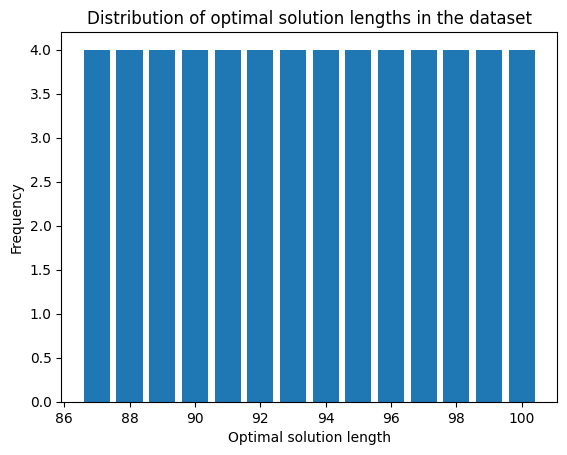

In [74]:
from matplotlib import pyplot as plt

plt.bar(freq_sol_length.keys(), freq_sol_length.values())
plt.xlabel("Optimal solution length")
plt.ylabel("Frequency")
plt.title("Distribution of optimal solution lengths in the dataset")
plt.show()

In [75]:
json.dump(results, open("./linear.json", "w"), indent=4)

In [54]:
len("lllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllll")

89